# Detecção de Fraudes em Transações de Cartão de Crédito

O projeto busca encontrar um modelo de classificação que detecte de forma eficaz as fraudes nas transações bancárias contidas na base de dados utilizada.  

As fraudes deste dataset foram levantadas em transações ocorridas em dois dias do mês de setembro de 2023.  

### Inspeção da base

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('CREDIT_CARD_FRAUD.csv', sep=',')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


A base se apresenta com 28 variáveis com o PCA aplicado. A técnica é usada em datasets com grande número de variáveis, e que tem por função reduzir a dimensionalidade do conjunto de dados, preservando a maior parte da variação presente nos dados originais.



Apenas as variáveis de tempo ('Time'), que representa os segundos decorridos de cada transação, e 'Amount', representando os valores das transações, estão em sua forma original, além da variável alvo, binária, 'Class'.

Dessa forma, não há demanda de análise exploratória, a não ser pelas variáveis originais, principalmente a target, para conferir seu balanceamento, e a variável 'Amount'.  

Não há presença de dados nulos.

## Análise das Distribuições

Tabela de dados estatísticos de cada variável:

In [ ]:
df.describe().round(2)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


A variável 'Amount' possui uma dispersão assimétrica, com mediana em 22.0 e média em 88.35, certamente elevada devido a transações de valores mais altos e extremos presentes na cauda da distribuição como vemos pelo valor máximo, de 25.691,16. A média chega a ultrapassar o valor do terceiro quartil, de 77,16.


### Análise da Variavel Alvo

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df['Class'].value_counts(normalize=True).round(3)

,proportion
Class,
0,0.998
1,0.002


O dataset está dividido entre registros com fraudes, representados pela classe 1, e os sem fraudes, pela classe 0.  

Esta é uma base bastante desequilibrada em favor das transações sem fraude detectada, como é de se esperar (as transações fraudulentas costumam formar apenas uma pequena minoria), com 284315 instâncias nesta classificação, e apenas 492 pertencentes à classe 1 (0.002%), e por isso demandará balanceamento.




### Análise da Variável 'Amount'

A variável 'Amount' representa os dados de valores de cada uma das transações:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

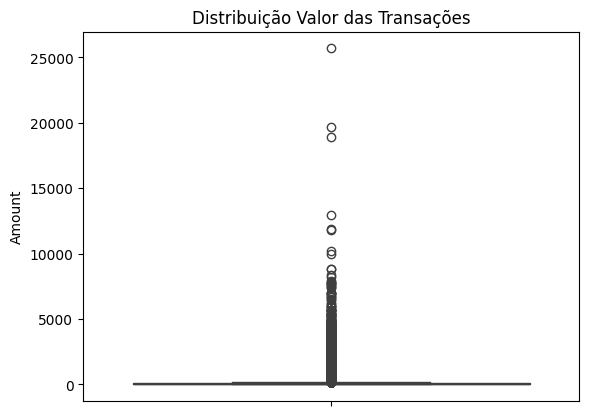

In [ ]:
import os
sns.boxplot(df['Amount'])
plt.title('Distribuição Valor das Transações')
plt.savefig('images/boxplot_amount.png')
plt.show()

O gráfico de caixa ilustra bem a distorção da distribuição desta variável, em que a caixa está bem achatada e se destacam os outliers.  

A seguir, análise desta variável com a target para verificar se pode haver alguma **relação de valor de transação com a classificação de fraude**.

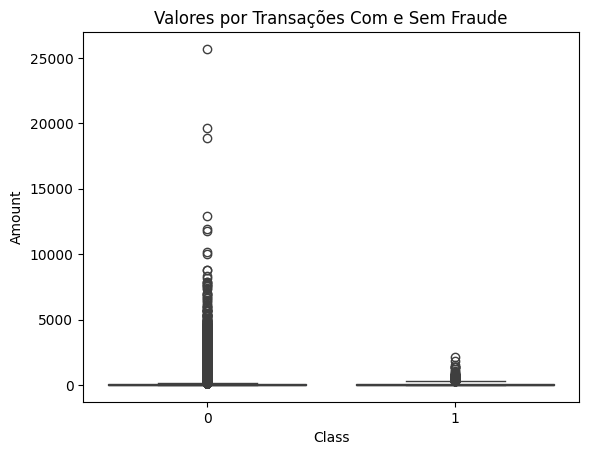

In [ ]:
sns.boxplot(df, x='Class', y='Amount')
plt.title('Valores por Transações Com e Sem Fraude')
plt.savefig('images/boxplot_amount_class.png')
plt.show()

In [ ]:
df.groupby('Class')["Amount"].max()

,Amount
Class,
0,25691.16
1,2125.87


Como vemos nesta comparação das distribuições de valores transacionados entre registros com e sem fraude, boa parte dos valores atípicos não estão entre os registros de fraudes. Estes estão limitados ao valor de 2.125,87.

### Correlações

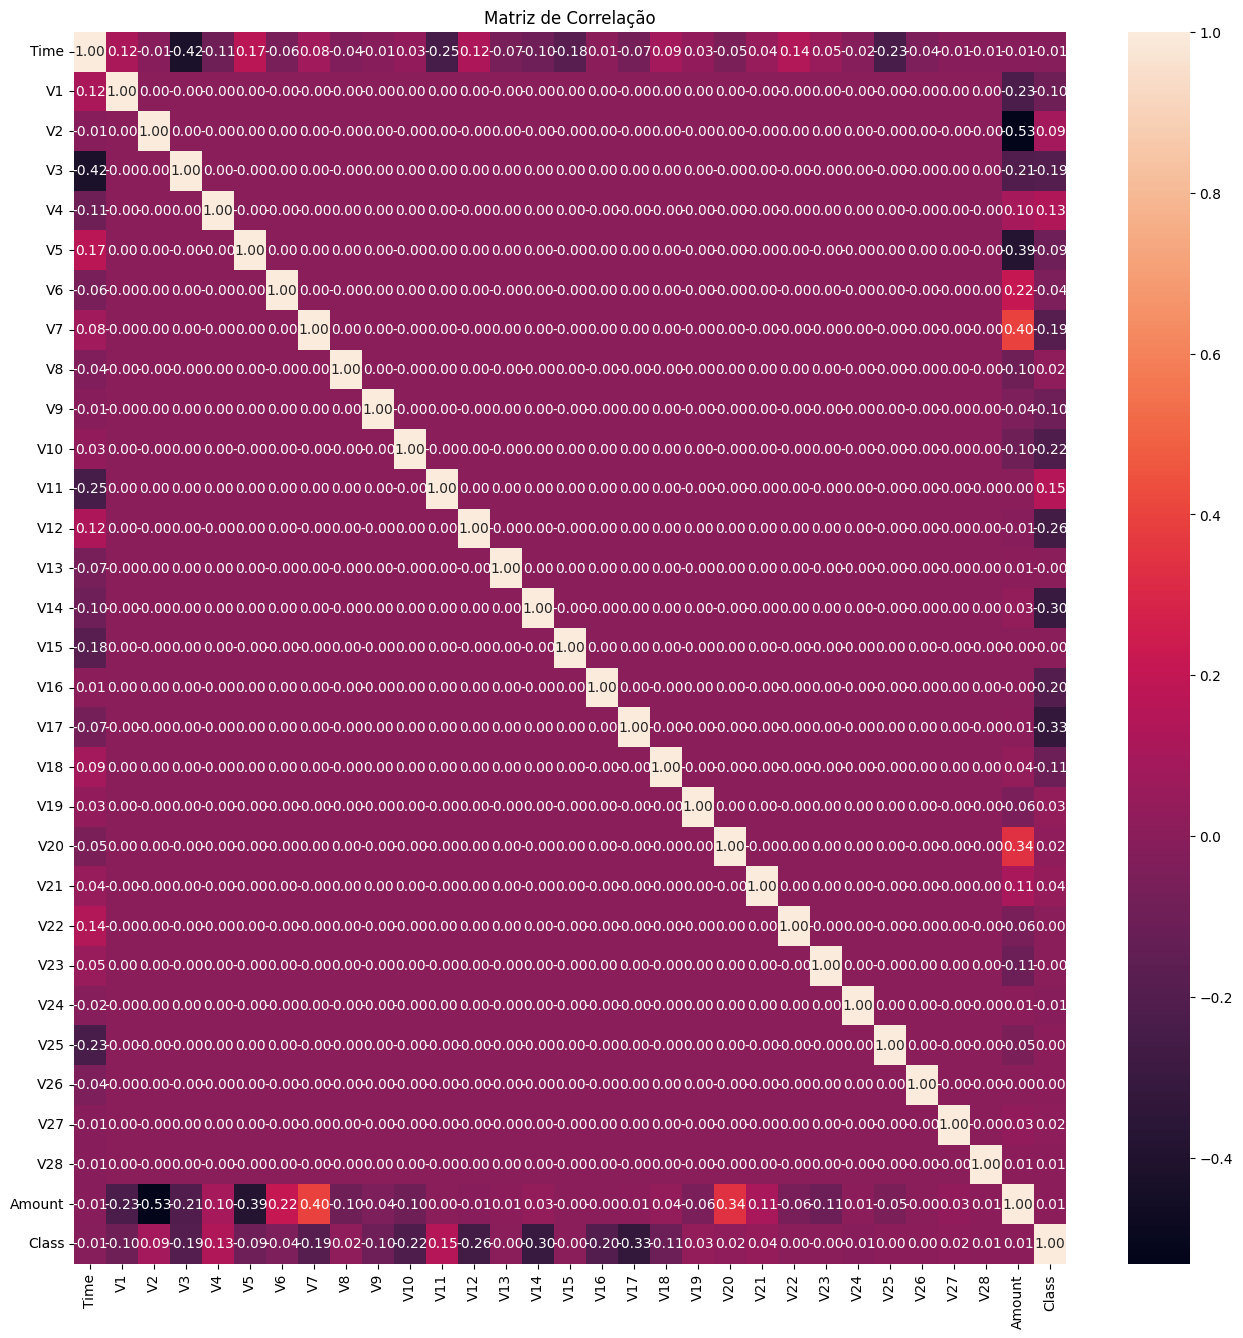

In [14]:
corr = df.corr()
plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket')
plt.title('Matriz de Correlação')
plt.savefig('images/matriz_correlacao.png')
plt.show()

- Algumas correlações com a Target que chamam atenção:  
V12: 26%  
V14: 30%  
V17: 33%  

- As variáveis originais 'Amount' e 'Time' não possuem correlação significativa com 'Class'.  

- Entre as variáveis independentes destaco:  
Amount x V5: 39%  
Time x V3: 42%  
Amount x V2: 53%  


Previamente ao treinamento dos modelos, além do necessário balanceamento, será aplicada técnica de normalização dos dados das variáveis 'Amount' e 'Time' para que fiquem em uma mesma escala.  
Para isso, será utilizado o **RobustScaler**, técnica que usa a mediana e os quartis das distribuições para realizar o reescalonamento dos dados, mas mantendo as distâncias entre os pontos de forma proporcional.  
Dessa forma, os valores atípicos presentes serão mantidos, mas suavizados.

## Pré-Processamento

A seguir:  
- Divisão dos dados em base treino e teste;
- Padronização de escala de 'Amount' e 'Time';
- Balanceamento da base

In [15]:
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

**Divisão base treino e teste:**

In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Nota: Utilização do argumento stratify acima para que a divisão das bases mantenha a proporção exata de registros de fraudes nas bases treino e teste.

**Padronização:**

In [18]:
scaler = RobustScaler()
colunas_padronizar = ['Amount', 'Time']
X_train[colunas_padronizar] = scaler.fit_transform(X_train[colunas_padronizar])
X_test[colunas_padronizar] = scaler.transform(X_test[colunas_padronizar])

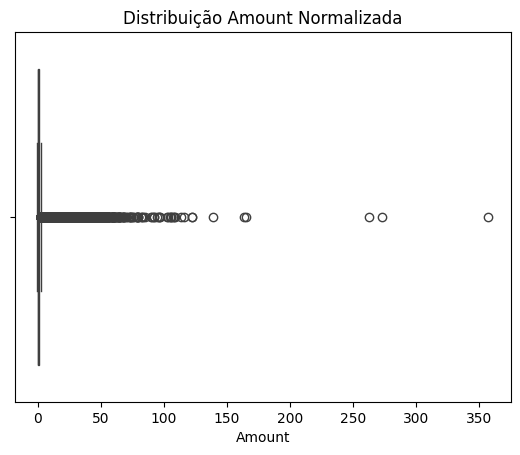

In [19]:
sns.boxplot(X_train, x='Amount')
plt.title('Distribuição Amount Normalizada')
plt.savefig('images/boxplot_amount_normalizado.png')
plt.show()

Conforme a visualização, vemos que o Robust Scaler manteve a assimetria dos dados, mas com uma escala reduzida.

**Balanceamento:**

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

In [22]:
# Conferência das dimensões da base treino balanceada:

X_train_balanceado.shape, y_train_balanceado.shape

((272941, 30), (272941,))

In [23]:
# Conferência do balanceamento na variável target:

y_train_balanceado.value_counts()

,count
Class,
0,227451
1,45490


Devido às dimensões do dataset, e tendo em vista que com um over-sampling comum ele pode dobrar de tamanho em relação ao original, é necessário ter algum critério na configuração da técnica de balanceamento.  
Com isso, a opção foi por não tornar as classes equivalentes, mas limitar a classe 1 em apenas 20% da classe majoritária.

## Modelagem

Opto por testar dois modelos lineares, um mais tradicional, o de **Regressão Logística**, e outro mais avançado, o **SVC**.  
Vou optar também por um método ensemble, o **XGBoost**, algoritmo que combina e extrai os melhores resultados de diversas árvores de decisão.

In [24]:
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Configuração de Hiperparâmetros para os modelos:

In [25]:
# Regressão Logística:

param_grid_logistica = {
    'C': [0.1, 1, 5],
    'penalty': ['l1', 'l2']
    }

In [26]:
# XGBooster:

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'subsample': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 1.5]
}

In [27]:
# SVM:

param_grid_svm = {
    'C': [0.1, 1, 5]
    }

Configuração do RandomizedSearch:

In [28]:
modelo_logistica = LogisticRegression(random_state=42)
modelo_xgb = xgb.XGBClassifier(random_state=42, tree_method='hist',)
modelo_svm = SVC(kernel='linear', random_state=42, max_iter=3000)

In [29]:
# Regressão Logística:

grid_logistica = RandomizedSearchCV(
    estimator=modelo_logistica,
    param_distributions=param_grid_logistica,
    n_iter=3,
    cv=3,
    verbose=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

In [30]:
# XGBooster:

grid_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=param_grid_xgb,
    n_iter=8,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

In [31]:
# SVM:

grid_svm = RandomizedSearchCV(
    estimator=modelo_svm,
    param_distributions=param_grid_svm,
    n_iter=3,
    cv=3,
    verbose=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

- No SVC será testado o kernel linear, embora menos flexível que o RBF, por razões de processamento.

- No RandomizedSearch foi configurado o tipo de métrica ('scoring') no qual os modelos devem se basear para gerar os melhores parâmetros:

- - A precisão e o recall geralmente se opõem, na medida em que se um
aumenta, o outro tende a diminuir.  

- - O recall alto tende a identificar mais fraudes corretamente, mas pode acabar barrando bons clientes.  

- - O foco na precisão por outro lado tende a deixar passar mais fraudes.  

- - Dessa forma, a opção foi pelo F1-score, que é o resultado da média harmônica entre as duas métricas.

### Treinamento

In [36]:
# Regressão Logística:

grid_logistica.fit(X_train_balanceado, y_train_balanceado)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3 fits failed out of a total of 9.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver(se

RandomizedSearchCV(cv=3, estimator=LogisticRegression(random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 5],
                                        'penalty': ['l1', 'l2']},
                   random_state=42, scoring='f1', verbose=2)

In [37]:
import joblib

joblib.dump(grid_logistica, 'modelo_logistica.pkl')

['modelo_logistica.pkl']

In [38]:
# XGBooster:

grid_xgb.fit(X_train_balanceado, y_train_balanceado)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [0.5, 1.0, 1.5],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1')

In [39]:
joblib.dump(grid_xgb, 'modelo_xgb.pkl')

['modelo_xgb.pkl']

In [40]:
# SVM:

grid_svm.fit(X_train_balanceado, y_train_balanceado)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=SVC(kernel='linear', max_iter=3000,
                                 random_state=42),
                   n_iter=3, n_jobs=-1, param_distributions={'C': [0.1, 1, 5]},
                   random_state=42, scoring='f1', verbose=2)

In [41]:
joblib.dump(grid_svm, 'modelo_svm.pkl')

['modelo_svm.pkl']

### Resultados

In [42]:
previsoes_logistica = grid_logistica.predict(X_test)
previsoes_xgb = grid_xgb.predict(X_test)
previsoes_svm = grid_svm.predict(X_test)

In [43]:
relatorio_logistica = classification_report(y_test, previsoes_logistica)
relatorio_xgb = classification_report(y_test, previsoes_xgb)
relatorio_svm = classification_report(y_test, previsoes_svm)

print("=== REGRESSÃO LOGÍSTICA ===\n", relatorio_logistica)
print("=== XGBOOST ===\n", relatorio_xgb)
print("=== SVM ===\n",relatorio_svm)

=== REGRESSÃO LOGÍSTICA ===
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.89      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.66     56962
weighted avg       1.00      0.99      1.00     56962

=== XGBOOST ===
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.87      0.85        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

=== SVM ===
               precision    recall  f1-score   support

           0       1.00      0.80      0.89     56864
           1       0.01      0.92      0.02        98

    accuracy                           0.80     56962
   macro avg       0.50      0.86      0.45     56962
weighted avg   

O modelo que teve a melhor performance considerando o F1-score da classe positiva foi o XGBoost, com média de 85%.  

Regressão Logística e SVM obtiveram médias bem inferiores, com 33% e 2%, respectivamente, devido ao baixo desempenho da precisão.  

Apesar de ter o maior índice de acerto no recall, o SVM erra praticamente todas as transações que ele afirma serem fraudes. O que significa que, se implementado em produção, bloquearia milhares de transações legítimas (20% - de acordo com o recall da classe 0 = 80%).  
Obs.: o modelo esteve limitado ao kernel linear e também a um número máximo de iterações estipulado devido a restrições de processamento.  

A Regressão Logística se sai bem também ao identificar corretamente 89% dos casos de fraude, mas também tem precisão baixa, de apenas 20%.  

O XGBoost obteve o resultado mais equilibrado para a classe 1, com precisão de 83% e recall de 87%, o que demonstra a capacidade de detectar de maneira razoável as fraudes quando realmente ocorrem.  

Por ter tido as melhores métricas, exibo abaixo a Matriz de Confusão com os resultados do XGBoost:



Matriz de Confusão

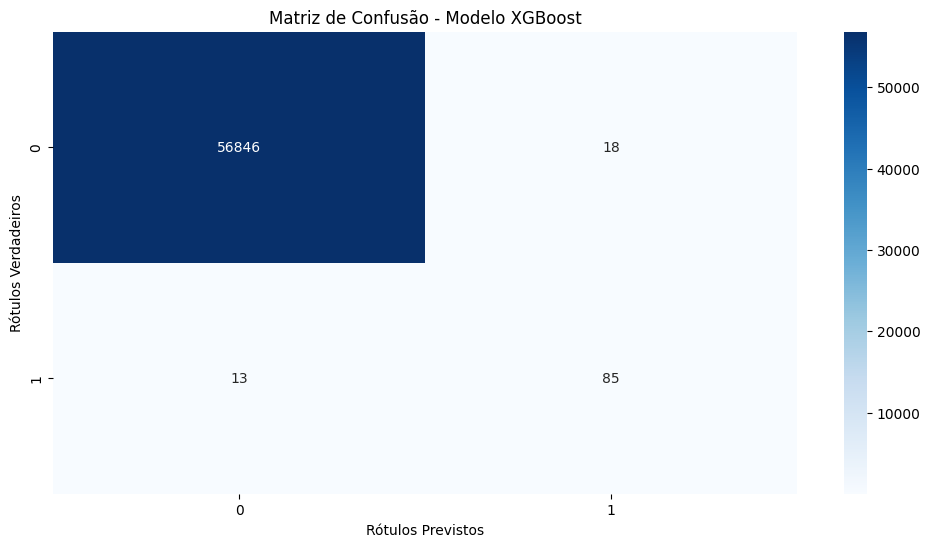

In [45]:
matriz = confusion_matrix(y_test, previsoes_xgb)
classes = ['0', '1']
plt.figure(figsize=(12, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Rótulos Previstos')
plt.ylabel('Rótulos Verdadeiros')
plt.title('Matriz de Confusão - Modelo XGBoost')
plt.savefig('images/matriz_confusao_xgb.png')
plt.show()

- Conforme vemos acima, o modelo previu corretamente 85 fraudes e deixou passar apenas 13 (recall de 87%).  

- Dos 103 casos em que apontou para fraude, o XGBoost acertou 85 casos e errou 18 (precisão de 83%).  

- No lado da classe 0, o modelo teve precisão de 100%, mas ainda assim por aqui vemos que houve 13 erros dentre os quase 57.000 casos.

Seguindo na análise, trago a visualização das curvas que ilustram o equilíbrio de cada modelo entre as métricas de precisão e recall. Como os dados são desbalanceados opto por plotar o gráfico da curva PR (Precision-Recall), que foca na classe positiva, sendo mais informativa em cenários como esse em que os positivos
são raros.

### Probabilidades, Precision-Recall e Gráfico

In [46]:
from sklearn.metrics import precision_recall_curve, auc

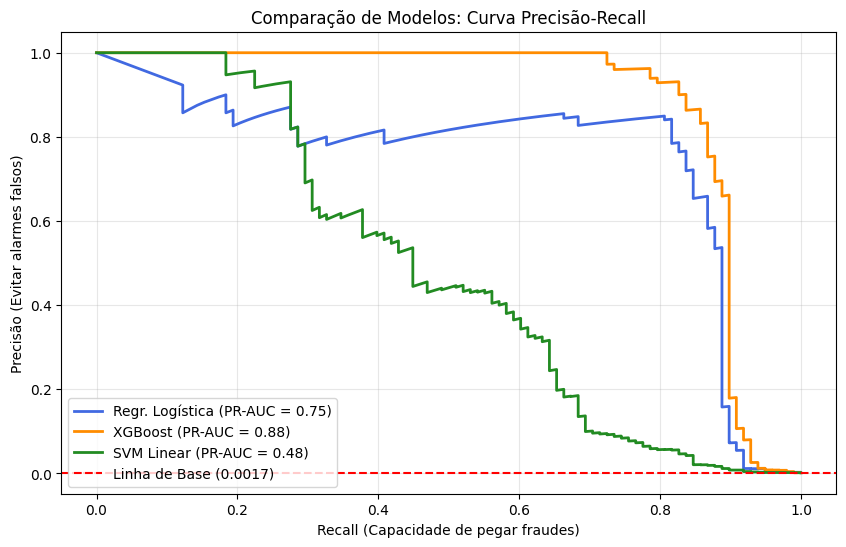

In [47]:
# 1. Probabilidades da classe 1 (Fraude) para cada modelo:

y_probs_log = grid_logistica.predict_proba(X_test)[:, 1]
y_probs_xgb = grid_xgb.predict_proba(X_test)[:, 1]
y_probs_svm = grid_svm.decision_function(X_test)

# 2. Precision, Recall e AUC:

# Regressão Logística
precision_log, recall_log, _ = precision_recall_curve(y_test, y_probs_log)
auc_log = auc(recall_log, precision_log)

# XGBooster
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)
auc_xgb = auc(recall_xgb, precision_xgb)

# SVM
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_probs_svm)
auc_svm = auc(recall_svm, precision_svm)

# 3. Gráfico de Comparação:

plt.figure(figsize=(10, 6))

plt.plot(recall_log, precision_log, label=f'Regr. Logística (PR-AUC = {auc_log:.2f})', color='royalblue', lw=2)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {auc_xgb:.2f})', color='darkorange', lw=2)
plt.plot(recall_svm, precision_svm, label=f'SVM Linear (PR-AUC = {auc_svm:.2f})', color='forestgreen', lw=2)

proporcao_fraudes = sum(y_test) / len(y_test)
plt.axhline(y=proporcao_fraudes, color='red', linestyle='--', label=f'Linha de Base ({proporcao_fraudes:.4f})')

plt.xlabel('Recall (Capacidade de pegar fraudes)')
plt.ylabel('Precisão (Evitar alarmes falsos)')
plt.title('Comparação de Modelos: Curva Precisão-Recall')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.savefig('images/curva_pr.png')
plt.show()


Como esperado, a curva amarela representando o XGBoost é a mais alta e à direita do que as demais, o que indica o maior equilíbrio entre as duas métricas.  
A curva azul, da Regressão Logística possui traçado similar, mas com maior oscilação na parte superior (menor precisão).  
A curva verde do SVM, pelo formato em diagonal, é a mais próxima do aleatório na classificação dos resultados.

### Ajuste no modelo

Pela melhor performance em termos de equilíbrio, que é o que foi buscado com o F1-score, o modelo selecionado para entrar em produção é o XGBoost.  

A opção foi por tornar o modelo menos rígido para detecção de fraudes para evitar o bloqueio de transações legítimas, em detrimento do risco de deixar passar algumas transações fraudulentas.  

Dessa forma a Precisão deve ser a métrica a ser elevada, em prejuízo do Recall.  

Prossigo para o ajuste do 'threshold', o limiar que regula o equilíbrio entre as duas métricas.  

Por padrão, o limiar é 0.5, isto é, qualquer probabilidade maior é considerada fraude, e vice-versa. Sendo assim, o modelo será calibrado com um limiar maior.  

Para isso será estabelecida a meta de Precisão = 90%, ou seja, estaremos estipulando que o modelo acerte 9 em cada 10 vezes em que classificar uma transação como fraude, resultando assim na elevação do limiar de probabilidades e na redução do recall:

In [48]:
# Recálculo da curva PR do XGBooster:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_probs_xgb)

# Meta:
meta_precisao = 0.90

# Encontrar o índice onde a precisão é maior ou igual à meta:
idx = np.where(precision_xgb >= meta_precisao)[0][0]

threshold_ideal = thresholds_xgb[idx]
recall_atingido = recall_xgb[idx]

print(f"Para garantir 90% de Precision:")
print(f"  -> O limiar (threshold) ideal do XGBoost deve ser: {threshold_ideal:.4f}")
print(f"  -> O Recall (captura de fraudes) cairá para: {recall_atingido*100:.2f}%\n")


Para garantir 90% de Precision:
  -> O limiar (threshold) ideal do XGBoost deve ser: 0.7378
  -> O Recall (captura de fraudes) cairá para: 83.67%



In [49]:
# Aplicação do novo threshold nos dados de teste para ver o novo relatório

y_pred_calibrado = (y_probs_xgb >= threshold_ideal).astype(int)

print("=== XGBOOST CALIBRADO (foco Precisão) ===")
print(classification_report(y_test, y_pred_calibrado))

=== XGBOOST CALIBRADO (foco Precisão) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Conforme relatório, vemos que para a classe 1, a meta de 90% de precisão fez o recall cair de 87% para 84%, mas subiu o F1-score de 85% para 87%. Dessa forma, a cada 100 transações fraudulentas, o modelo ainda captará 84 delas.

Exportação de componentes do projeto:

In [50]:
# Extração do modelo XGBoost
melhor_xgb = grid_xgb.best_estimator_
joblib.dump(melhor_xgb, 'modelo_xgb.pkl')

# RobustScaler
joblib.dump(scaler, 'robust_scaler.pkl')

# Limiar de probabilidades calibrado
joblib.dump(threshold_ideal, 'threshold_calibrado.pkl')

print("Componentes salvos com sucesso")

Componentes salvos com sucesso


Importância de variáveis:

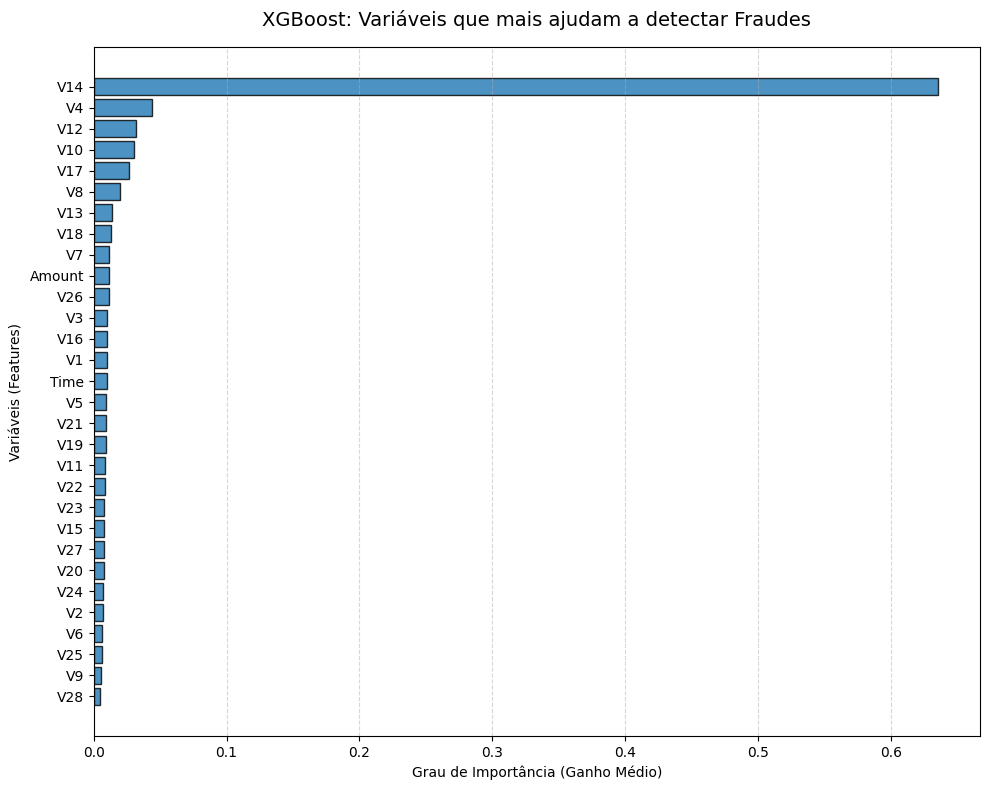

In [52]:
importancias = melhor_xgb.feature_importances_

df_importancia = pd.DataFrame(
    {"Variavel": X_train.columns, "Importancia": importancias}).sort_values(by="Importancia", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(
    df_importancia["Variavel"],
    df_importancia["Importancia"],
    edgecolor="black",
    alpha=0.8,
)

plt.xlabel("Grau de Importância (Ganho Médio)")
plt.ylabel("Variáveis (Features)")
plt.title(
    "XGBoost: Variáveis que mais ajudam a detectar Fraudes",
    fontsize=14,
    pad=15,
)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('images/importancia_variaveis.png')
plt.show()


Acima vemos as variáveis mais relevantes para o modelo classificar as fraudes. Assim como visto na análise de correlações, a feature V14 se destaca bem acima das demais. Essa variável foi a mais usada para dividir os dados nas árvores do modelo, sendo a que mais influncia nas decisões de classificação.

## Conclusão

Neste projeto procurei implementar um fluxo completo de ciência de dados para a detecção das fraudes, incluindo:  

Tratamento de Dados:  
- A técnica de padronização utilizada, RobustScaler, permitiu a suavização dos outliers na variável 'Amount', principalmente para não prejudicar o desempenho dos algoritmos lineares.

Balanceamento:  
- Técnica utilizada SMOTE com limitação da geração de amostras de 20% para evitar volume de processamento.  

Modelos:  
- Três algoritmos diferentes foram utilizados para comparação de métricas, com SVM e Regressão Logística atingindo boas taxas de recall, mas com baixa precisão de acertos de fraudes. O modelo XGBoost, considerado o superior, obteve o maior equilíbrio entre as métricas. O modelo foi calibrado para atender à necessidade de menos bloqueios de transações legítimas.

